In [ ]:
import requests
from PIL import Image

import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
import os
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore')

# Model

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '4'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [3]:
model_id = "llava-hf/llava-1.5-7b-hf"
model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    low_cpu_mem_usage=True, 
).to(device)

processor = AutoProcessor.from_pretrained(model_id)


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  8.73it/s]
Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens. 


# Example run

In [4]:
conversation = [
    {

      "role": "user",
      "content": [
          {"type": "text", "text": "Describe the image in detail."},
          {"type": "image"},
        ],
    },
]
prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)


In [5]:
image_file = "http://images.cocodataset.org/val2017/000000336232.jpg"
raw_image = Image.open(requests.get(image_file, stream=True).raw)
inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(device, torch.float16)

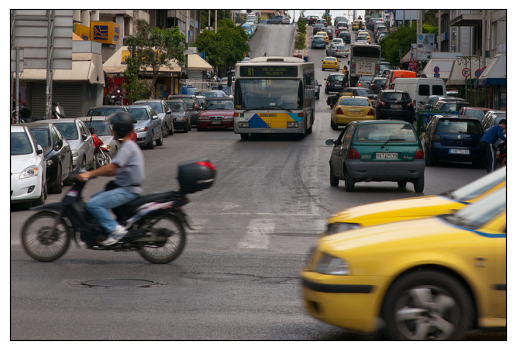

In [6]:
plt.imshow(raw_image)
plt.xticks([])
plt.yticks([])
plt.show()

In [7]:
strength = 0

output = model.generate(**inputs, max_new_tokens=512, do_sample=True)
print(processor.decode(output[0][2:], skip_special_tokens=True))

Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


ER:  
Describe the image in detail. ASSISTANT: The image depicts a busy city street with a man on a scooter navigating through traffic. Several cars and other vehicles are parked or lined up along the street, including one yellow taxi. In addition to the vehicles, there are a couple of people walking along the sidewalk. A stop sign can be seen on one side of the street, and a parking meter further down the road. The scene gives the impression of a bustling urban environment with a variety of transportation modes in use.


## Forward hook reminder

In [8]:
target_layer = 20
concept = None

def remind_image(target_layer):
    global concept, strength
    def hook(model, input, output):
        global concept, strength
        if (output[0].shape[1] != 1):
            concept = torch.mean(output[0], dim=1)
        else:
            output = (output[0] + strength*concept, *output[1:])
        return output
    return hook


hook = model.language_model.model.layers[target_layer].self_attn.register_forward_hook(remind_image(target_layer))

In [9]:
strength = 2

output = model.generate(**inputs, max_new_tokens=512, do_sample=True, top_k=None, top_p=1, temperature=1)
print(processor.decode(output[0][2:], skip_special_tokens=True))

ER:  
Describe the image in detail. ASSISTANT: The image depicts a busy street filled with numerous cars, a person on a motorcycle, and other vehicles moving in multiple directions. In the center of the scene, there is a large yellow bus driving down the street, garnering attention. Several cars are scattered around the street, some behind the yellow bus and others that appear to be further up the road. 

In addition to the people riding in the cars, there are two pedestrians present within the scene, possibly walking or taking a break from the traffic. The motorcycle is ridden by a person, either inside or standing next to it, which adds to the fast-moving atmosphere of the street scene.
